# Step 5: Resident-Mutant Invasion in K-Player EWL Games

## TL;DR

This notebook reports the reproducible `gamma=pi/2` baseline analysis for
`K=2,3,4,5`. It reads the complete saved search artifacts; it does not replace
the rare-limit ESS calculation with a single-frequency plot.

- Six canonical symmetric finite-grid Nash residents were screened.
- The `K=3` resident `(pi/2,pi/2)` and the lower-payoff `K=5` resident
  `(pi/2,pi/2)` have robust higher-order invaders and are `not_ESS`.
- Four other residents had no positive invader after grid refinement and
  continuous search, but distinct near-resident mutants were neutral within
  `1e-8`; they remain `neutral_or_weak_candidate`, not proven ESSs.
- All saved optimizer runs converged, and probability, polynomial, and
  permutation residuals remained far below the declared tolerance.


## Context and method

The authoritative Step 1-4 baseline is commit
`5827d9aaf631f67a02713eb8643609a7730707d2`. Strategies use the restricted EWL
family on `[0,pi] x [0,pi/2]`; the duplicate `theta=pi` boundary is represented
once. The project uses exact noiseless statevectors, pairwise-summed
Prisoner's Dilemma payoffs `(R,S,T,P)=(3,0,5,1)`, and its global
parity-adjusted K-body entangler.

For a focal type `X`, let `u_X(j;R,M)` be its payoff when `j` of its `K-1`
co-players are mutants. Independent random sampling in an infinite well-mixed
population gives

$$
\Pi_X(\epsilon)=\sum_{j=0}^{K-1}\binom{K-1}{j}
\epsilon^j(1-\epsilon)^{K-1-j}u_X(j;R,M).
$$

The invasion advantage is
`DeltaPi(epsilon)=Pi_M(epsilon)-Pi_R(epsilon)`. It is a polynomial of degree at
most `K-1`; the sign of its first coefficient above `1e-8` determines the rare
mutant classification. `DeltaPi(0.01)` below is a diagnostic, not the ESS
definition. Full equations and limitations are in `docs/step5_methods.md`.


In [1]:
from pathlib import Path
import json
import math

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from quantum_ess import (
    EWL_C,
    EWL_D,
    KPlayerEWLGame,
    analyze_resident_mutant,
    exactly_one_mutant_group_diagnostic,
)

ROOT = Path.cwd()
RESULTS = ROOT / "results" / "step5"

summary = pd.read_csv(RESULTS / "resident_summary.csv")
candidates = pd.read_csv(RESULTS / "symmetric_nash_candidates.csv")
details = pd.read_csv(RESULTS / "resident_mutant_pair_results.csv.gz")
optimizers = pd.read_csv(RESULTS / "continuous_optimizer_runs.csv")
landscape = pd.read_csv(RESULTS / "landscape_points.csv")
metadata = json.loads((RESULTS / "run_metadata.json").read_text())

print(f"Loaded {len(details):,} position-resolved pair rows.")
print(f"Loaded {len(summary)} resident summaries and {len(optimizers)} optimizer runs.")


Loaded 5,487 position-resolved pair rows.
Loaded 6 resident summaries and 16 optimizer runs.


## Data integrity checks

In [2]:
required_k = {2, 3, 4, 5}
assert set(candidates["k"]) == required_k
assert len(summary) == len(candidates) == 6
assert details["k"].isin(required_k).all()
assert details["probability_error"].max() < 1e-8
assert details["polynomial_reconstruction_error"].max() < 1e-8
assert details["permutation_error"].max() < 1e-8
assert optimizers["differential_evolution_success"].all()
assert metadata["authoritative_baseline_commit"].startswith("5827d9a")

qa = pd.Series({
    "candidate_count": len(candidates),
    "pair_position_rows": len(details),
    "optimizer_runs": len(optimizers),
    "all_global_runs_converged": bool(
        optimizers["differential_evolution_success"].all()
    ),
    "maximum_probability_error": f'{details["probability_error"].max():.6e}',
    "maximum_polynomial_error": (
        f'{details["polynomial_reconstruction_error"].max():.6e}'
    ),
    "maximum_permutation_error": f'{details["permutation_error"].max():.6e}',
})
display(qa.to_frame("value"))


,value
candidate_count,6
pair_position_rows,5487
optimizer_runs,16
all_global_runs_converged,True
maximum_probability_error,3.330669e-15
maximum_polynomial_error,3.552714e-15
maximum_permutation_error,2.486900e-14


## Resident screening and final classifications

In [3]:
resident_results = summary.merge(
    candidates[[
        "k", "gamma", "resident_theta", "resident_phi", "resident_payoff",
        "maximum_unilateral_gain",
    ]],
    on=["k", "gamma", "resident_theta", "resident_phi"],
    how="left",
    validate="one_to_one",
)

display_columns = [
    "k", "resident_theta", "resident_phi", "resident_payoff",
    "maximum_unilateral_gain", "resident_status",
    "maximum_mutant_advantage_at_epsilon_reference",
    "strongest_mutant_theta", "strongest_mutant_phi",
    "number_of_robust_invaders", "number_of_neutral_mutants",
]
resident_display = resident_results[display_columns].copy()
for column in (
    "resident_theta", "resident_phi", "resident_payoff",
    "maximum_unilateral_gain",
    "maximum_mutant_advantage_at_epsilon_reference",
    "strongest_mutant_theta", "strongest_mutant_phi",
):
    resident_display[column] = resident_display[column].map(
        lambda value: f"{value:.10g}"
    )
display(resident_display)


,k,resident_theta,resident_phi,resident_payoff,maximum_unilateral_gain,resident_status,maximum_mutant_advantage_at_epsilon_reference,strongest_mutant_theta,strongest_mutant_phi,number_of_robust_invaders,number_of_neutral_mutants
0,2,0,1.570796327,3,0,neutral_or_weak_candidate,-1.364508506e-11,3.588983966e-07,1.57079375,0,4
1,3,1.570796327,1.570796327,4.5,3.552713679e-15,not_ESS,0.0233155948,0,0.9424777961,13,0
2,4,0,1.570796327,9,0,neutral_or_weak_candidate,-3.396394277e-12,1.018875356e-06,1.570795918,0,4
3,4,1.570796327,1.570796327,6.75,2.664535259e-15,neutral_or_weak_candidate,2.664535259e-15,1.570796317,1.570796327,0,3
4,5,0,1.256637061,12,0,neutral_or_weak_candidate,3.552713679e-15,0,1.256637058,0,30
5,5,1.570796327,1.570796327,9,5.329070518e-15,not_ESS,2.412111963e-06,1.570796327,0.6283185307,2,0


The two `not_ESS` results are finite-grid Nash residents whose
order-zero mutant advantage is tied. They fail only when higher-order terms
capture encounters among mutants. This is the direct computational distinction
between Nash equilibrium and evolutionary stability.

In [4]:
invaders = (
    details.loc[
        (details["search_stage"] == "coarse")
        & (details["rare_mutant_classification"] == "rare_mutant_invades")
    ]
    .sort_values("DeltaPi_epsilon_reference", ascending=False)
    .drop_duplicates([
        "k", "resident_theta", "resident_phi", "mutant_theta", "mutant_phi"
    ])
)

strongest_invaders = (
    invaders.groupby(["k", "resident_theta", "resident_phi"], as_index=False)
    .head(1)[[
        "k", "resident_theta", "resident_phi", "mutant_theta", "mutant_phi",
        "leading_nonzero_order", "leading_coefficient",
        "Pi_R_epsilon_reference", "Pi_M_epsilon_reference",
        "DeltaPi_epsilon_reference",
    ]]
)
display(strongest_invaders.round(10))


,k,resident_theta,resident_phi,mutant_theta,mutant_phi,leading_nonzero_order,leading_coefficient,Pi_R_epsilon_reference,Pi_M_epsilon_reference,DeltaPi_epsilon_reference
644,3,1.570796,1.570796,0.000000,0.942478,1.0,2.331559,4.499879,4.523194,0.023316
5347,5,1.570796,1.570796,1.570796,0.628319,3.0,2.425975,9.000000,9.000002,0.000002


## Fixed-group diagnostic versus population ESS

In [5]:
game = KPlayerEWLGame(k=5, gamma=math.pi / 2)
fixed_group = exactly_one_mutant_group_diagnostic(game, EWL_C, EWL_D)
population = analyze_resident_mutant(
    game=game,
    resident=EWL_C,
    mutant=EWL_D,
    epsilon_reference=0.01,
)
rare = population.position_results[0]

comparison = pd.Series({
    "fixed_group_mutant_payoff": fixed_group.mutant_payoff,
    "fixed_group_resident_payoff": fixed_group.resident_average_payoff,
    "fixed_group_difference": fixed_group.mutant_minus_group_resident,
    "population_leading_order": rare.leading_nonzero_order,
    "population_leading_advantage": rare.leading_coefficient,
    "population_classification": rare.rare_mutant_classification,
})
display(comparison.to_frame("value"))


,value
fixed_group_mutant_payoff,20.0
fixed_group_resident_payoff,9.0
fixed_group_difference,11.0
population_leading_order,0
population_leading_advantage,8.0
population_classification,rare_mutant_invades


The fixed group returns `20-9=11`. The rare-population leading
term is `20-12=8`, because a resident focal individual in an almost entirely
resident population normally meets four cooperators and earns 12. Step 5 uses
the latter population definition.

## Mutant invasion landscapes

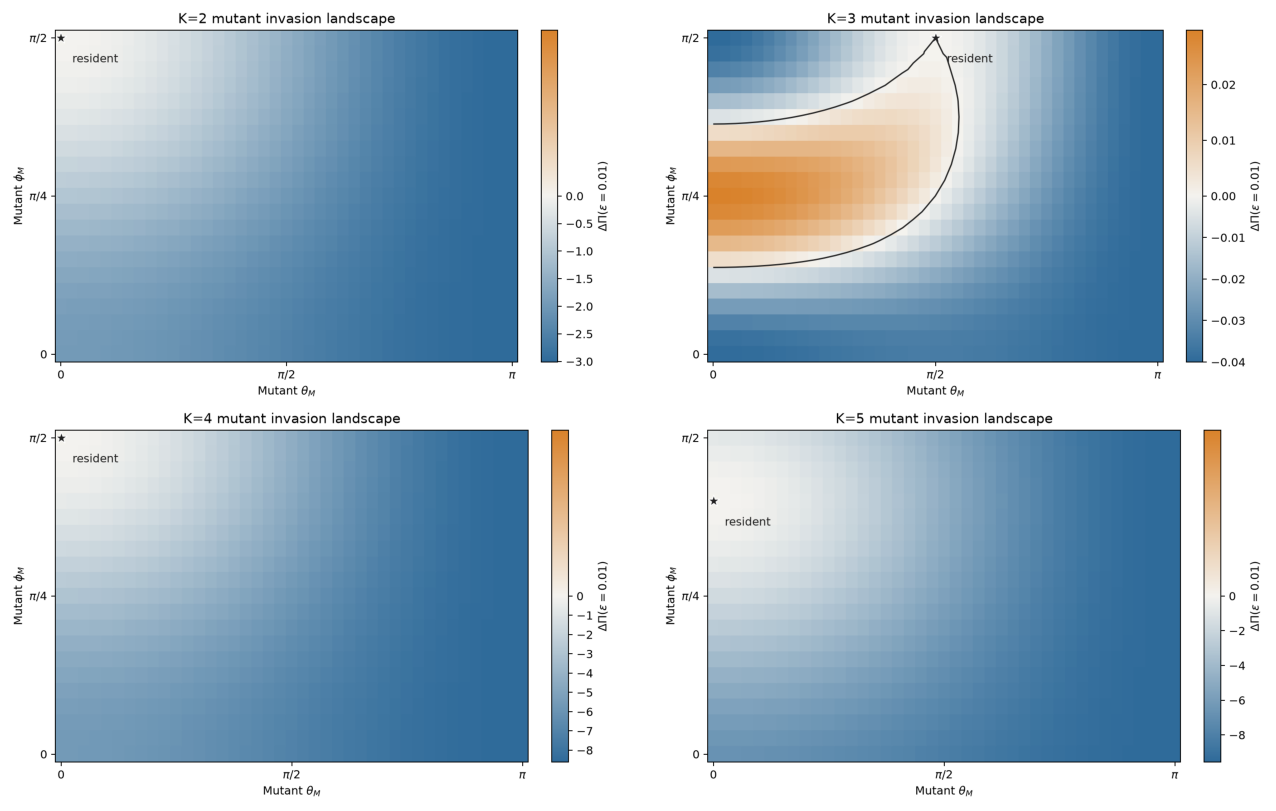

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
for axis, k in zip(axes.flat, (2, 3, 4, 5)):
    image = plt.imread(RESULTS / "figures" / f"k{k}_mutant_invasion_landscape.png")
    axis.imshow(image)
    axis.axis("off")
plt.show()


Blue indicates negative mutant advantage at `epsilon=0.01`, white
is near zero, and orange is positive. The star marks the highest-payoff
symmetric Nash resident selected for each `K`. The `K=3` landscape visibly
contains an invading region. The color value is diagnostic; rare-limit labels
still come from polynomial coefficients.

## Coarse-to-fine and continuous evidence

In [7]:
evidence = resident_results[[
    "k", "resident_theta", "resident_phi", "coarse_grid_result",
    "fine_grid_result", "continuous_optimizer_result", "permutation_error",
]].copy()
display(evidence)

optimizer_summary = optimizers.groupby(
    ["k", "resident_theta", "resident_phi"], as_index=False
).agg(
    objectives=("objective_epsilon", "count"),
    all_global_runs_converged=("differential_evolution_success", "all"),
    total_global_evaluations=("differential_evolution_evaluations", "sum"),
    maximum_objective_advantage=("best_objective_advantage", "max"),
)
display(optimizer_summary.round(10))


,k,resident_theta,resident_phi,coarse_grid_result,fine_grid_result,continuous_optimizer_result,permutation_error
0,2,0.000000,1.570796,grid_ESS_candidate; mutants=60; max_delta_refe...,grid_ESS_candidate; mutants=247; max_delta_ref...,neutral_or_weak_candidate; candidates=10; all_...,4.440892e-16
1,3,1.570796,1.570796,not_ESS; mutants=60; max_delta_reference=0.023...,not_run_not_apparent_stable,not_run_not_fine_grid_stable,2.664535e-15
2,4,0.000000,1.570796,grid_ESS_candidate; mutants=60; max_delta_refe...,grid_ESS_candidate; mutants=247; max_delta_ref...,neutral_or_weak_candidate; candidates=10; all_...,5.329071e-15
3,4,1.570796,1.570796,grid_ESS_candidate; mutants=60; max_delta_refe...,grid_ESS_candidate; mutants=252; max_delta_ref...,neutral_or_weak_candidate; candidates=23; all_...,7.993606e-15
4,5,0.000000,1.256637,grid_ESS_candidate; mutants=60; max_delta_refe...,grid_ESS_candidate; mutants=256; max_delta_ref...,neutral_or_weak_candidate; candidates=37; all_...,2.486900e-14
5,5,1.570796,1.570796,not_ESS; mutants=60; max_delta_reference=2.412...,not_run_not_apparent_stable,not_run_not_fine_grid_stable,8.881784e-15


,k,resident_theta,resident_phi,objectives,all_global_runs_converged,total_global_evaluations,maximum_objective_advantage
0,2,0.000000,1.570796,4,True,3540,0.0
1,4,0.000000,1.570796,4,True,4180,0.0
2,4,1.570796,1.570796,4,True,4700,0.0
3,5,0.000000,1.256637,4,True,3420,0.0


## Takeaways and limitations

1. A symmetric finite-grid Nash equilibrium can fail the multiplayer
   rare-mutant test at order 1 or even order 3. Nash is necessary for a pure
   ESS candidate but is not sufficient.
2. The `K=5` resident `(0,2pi/5)` remains the strongest Step 5 candidate: all
   residents earn 12 and no positive invader was found. Its current status is
   still conservative because numerical near-self neutrality prevents a strict
   claim.
3. These are pure-strategy numerical results in the restricted EWL family and
   this project's global K-body entangler. They do not establish an analytical
   result over full `SU(2)`, mixed strategies, other multiplayer entanglers, or
   noise.
4. Exact statevectors remove shot uncertainty, but optimizer coverage and the
   `1e-8` classification tolerance remain numerical limitations.
5. The next defensible extension is to preserve these baseline definitions
   while sweeping entanglement; noise should be introduced only in the later
   robustness model and reported with its own uncertainty assumptions.


## Reproducibility metadata

In [8]:
print(json.dumps(metadata["parameters"], indent=2, sort_keys=True))
print("Authoritative baseline:", metadata["authoritative_baseline_commit"])
print("Working-tree HEAD at run:", metadata["working_tree_head_at_run"])
print("Command:", " ".join(metadata["command"]))
print("Python:", metadata["python"].splitlines()[0])
print("Platform:", metadata["platform"])


{
  "chunksize": 8,
  "coarse_phi_count": 6,
  "coarse_theta_count": 11,
  "continuous_workers": 8,
  "differential_maxiter": 200,
  "differential_popsize": 10,
  "epsilon_reference": 0.01,
  "fine_phi_count": 11,
  "fine_theta_count": 21,
  "gamma": 1.5707963267948966,
  "k_values": [
    2,
    3,
    4,
    5
  ],
  "landscape_phi_count": 21,
  "landscape_theta_count": 41,
  "local_start_limit": 8,
  "optimizer_tolerance": 1e-08,
  "output_dir": "/Users/xincui/Documents/Q.ESS/results/step5",
  "seed": 20260826,
  "skip_continuous": false,
  "tolerance": 1e-08,
  "workers": 8
}
Authoritative baseline: 5827d9aaf631f67a02713eb8643609a7730707d2
Working-tree HEAD at run: 5827d9aaf631f67a02713eb8643609a7730707d2
Command: examples/step5_ess_analysis.py --workers 8 --continuous-workers 8
Python: 3.12.3 (main, Apr  9 2024, 08:09:14) [Clang 15.0.0 (clang-1500.3.9.4)]
Platform: macOS-26.5.1-arm64-arm-64bit
